# Global Tourism Data Analysis

**Dataset:** Global Tourism Statistics  
**Source:** UNWTO Tourism Data (Data Warehouse – Gold Layer)

This notebook explores global tourism data to understand how tourism has changed over time across different countries.

The data comes from a SQL Server data warehouse and covers domestic tourism, international arrivals, departures, tourism industries, and economic indicators.

---

### What this notebook shows:

- Load data from a Data Warehouse
- Check and understand the datasets
- Join fact tables with dimension tables
- Explore data using summary statistics
- Visualize tourism trends over time
- Compare countries and tourism patterns
- Analyze major events such as the Covid-19 shock


### 1. Import Libraries and SQL connection

In [1]:
import pyodbc
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pyodbc.drivers()

['SQL Server',
 'SQL Server Native Client RDA 11.0',
 'ODBC Driver 17 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [3]:
DRIVER = 'ODBC Driver 17 for SQL Server'
SERVER = 'DESKTOP-J3FRNGE\SQLEXPRESS'
DATABASE = 'TourismDB'

In [4]:
engine = create_engine(
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    f"?driver={DRIVER.replace(' ','+')}"
    "&trusted_connection=yes"
)
connection = engine.connect()

In [5]:
df1_domestic = pd.read_sql_query("SELECT * FROM TourismDB.gold.fact_domestic_tourism", connection)
df2_inbound = pd.read_sql_query("SELECT * FROM TourismDB.gold.fact_inbound_tourism", connection)
df3_outbound = pd.read_sql_query("SELECT * FROM TourismDB.gold.fact_outbound_tourism", connection)
df4_industries = pd.read_sql_query("SELECT * FROM TourismDB.gold.fact_tourism_industries", connection)
df5_sdg = pd.read_sql_query("SELECT * FROM TourismDB.gold.fact_sdg", connection)
df_country = pd.read_sql_query("SELECT * FROM TourismDB.gold.dim_country", connection)
df_year = pd.read_sql_query("SELECT * FROM TourismDB.gold.dim_year", connection)
df_indicator = pd.read_sql_query("SELECT * FROM TourismDB.gold.dim_indicator", connection)
df_units = pd.read_sql_query("SELECT * FROM TourismDB.gold.dim_unit_of_measure", connection)

### 2. Data Understanding and Initial Exploration

#### 2.1 Analyze gold.fact_domestic table

In [6]:
df1_domestic.head(10)

,Country_key,Indicator_key,Year_key,Units_key,Value
0,2,29,24,4,476.0
1,2,29,25,4,469.0
2,2,29,26,4,372.0
3,2,29,27,4,546.0
4,2,29,28,4,683.0
5,2,31,24,4,931.0
6,2,31,25,4,1104.0
7,2,31,26,4,800.0
8,2,31,27,4,1155.0
9,2,31,28,4,1339.0


In [7]:
df1_domestic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9015 entries, 0 to 9014
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country_key    9015 non-null   int64  
 1   Indicator_key  9015 non-null   int64  
 2   Year_key       9015 non-null   int64  
 3   Units_key      9015 non-null   int64  
 4   Value          9015 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 352.3 KB


In [8]:
df1_domestic.duplicated().sum()

np.int64(0)

In [9]:
df1_domestic['Value'].describe()

count    9.015000e+03
mean     5.106836e+04
std      2.138985e+05
min      0.000000e+00
25%      8.035000e+02
50%      6.151000e+03
75%      2.788500e+04
max      6.005852e+06
Name: Value, dtype: float64

#### 2.2 Analyze gold.fact_inbound table

In [10]:
df2_inbound.head(10)

,Country_key,Indicator_key,Year_key,Units_key,Value
0,2,14,24,4,767.0
1,2,14,25,4,785.0
2,2,14,26,4,294.0
3,2,14,27,4,685.0
4,2,14,28,4,887.0
5,2,16,24,4,2144.0
6,2,16,25,4,2150.0
7,2,16,26,4,805.0
8,2,16,27,4,2031.0
9,2,16,28,4,2492.0


In [11]:
df2_inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97260 entries, 0 to 97259
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country_key    97260 non-null  int64  
 1   Indicator_key  97260 non-null  int64  
 2   Year_key       97260 non-null  int64  
 3   Units_key      97260 non-null  int64  
 4   Value          97260 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 3.7 MB


In [12]:
df2_inbound.duplicated().sum()

np.int64(0)

In [13]:
df2_inbound['Value'].describe()

count     97260.000000
mean       4114.525927
std       14868.876763
min           0.000000
25%          43.000000
50%         323.000000
75%        1850.000000
max      355059.000000
Name: Value, dtype: float64

#### 2.3 Analyze gold.fact_outbound table

In [14]:
df3_outbound.head(10)

,Country_key,Indicator_key,Year_key,Units_key,Value
0,2,35,7,4,955.0
1,2,35,8,4,1303.0
2,2,35,9,4,1350.0
3,2,35,10,4,1694.0
4,2,35,11,4,2097.0
5,2,35,12,4,2616.0
6,2,35,13,4,2979.0
7,2,35,14,4,3716.0
8,2,35,15,4,3404.0
9,2,35,16,4,3443.0


In [15]:
df3_outbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17231 entries, 0 to 17230
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country_key    17231 non-null  int64  
 1   Indicator_key  17231 non-null  int64  
 2   Year_key       17231 non-null  int64  
 3   Units_key      17231 non-null  int64  
 4   Value          17231 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 673.2 KB


In [16]:
df3_outbound.duplicated().sum()

np.int64(0)

In [17]:
df3_outbound['Value'].describe()

count     17231.000000
mean       4903.719084
std       14623.383789
min           0.000000
25%          72.000000
50%         414.000000
75%        2715.000000
max      277265.000000
Name: Value, dtype: float64

#### 2.4 Analyze gold.fact_industries table

In [18]:
df4_industries.head(10)

,Country_key,Indicator_key,Year_key,Units_key,Value
0,2,41,24,2,1021.0
1,2,41,25,2,1126.0
2,2,41,26,2,1237.0
3,2,41,27,2,1256.0
4,2,41,28,2,1385.0
5,2,42,8,2,2283.0
6,2,42,9,2,2337.0
7,2,42,10,2,2376.0
8,2,42,11,2,4341.0
9,2,42,12,2,4834.0


In [19]:
df4_industries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20028 entries, 0 to 20027
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country_key    20028 non-null  int64  
 1   Indicator_key  20028 non-null  int64  
 2   Year_key       20028 non-null  int64  
 3   Units_key      20028 non-null  int64  
 4   Value          20028 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 782.5 KB


In [20]:
df4_industries.duplicated().sum()

np.int64(0)

In [21]:
df4_industries['Value'].describe()

count    2.002800e+04
mean     6.414523e+04
std      2.863974e+05
min      1.200000e-01
25%      4.110000e+01
50%      7.420000e+02
75%      1.633675e+04
max      5.491227e+06
Name: Value, dtype: float64

#### 2.5 Analyze gold.fact_sdg table 

In [22]:
df5_sdg.head(10)

,Country_key,Indicator,Year_key,Units_key,Value
0,2,SDG_8.9.1_GDP,14,3,2.76
1,2,SDG_8.9.1_GDP,15,3,2.67
2,2,SDG_8.9.1_GDP,16,3,2.81
3,2,SDG_8.9.1_GDP,17,3,2.53
4,2,SDG_8.9.1_GDP,18,3,2.36
5,2,SDG_8.9.1_GDP,19,3,2.32
6,2,SDG_8.9.1_GDP,20,3,2.33
7,2,SDG_8.9.1_GDP,21,3,2.44
8,2,SDG_8.9.1_GDP,22,3,2.64
9,2,SDG_8.9.1_GDP,23,3,2.84


In [23]:
df5_sdg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9545 entries, 0 to 9544
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country_key  9545 non-null   int64  
 1   Indicator    9545 non-null   object 
 2   Year_key     9545 non-null   int64  
 3   Units_key    9545 non-null   int64  
 4   Value        9545 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 373.0+ KB


In [24]:
df5_sdg.duplicated().sum()

np.int64(3076)

> **Data note:**
>The SDG dataset contains multiple rows for the same country and year for indicator SDG 12.b.1.  
>The SDG 12.b.1 indicator includes different reporting series 
>(SEEA tables, Tourism Satellite Account tables, and standard accounting tables), 
so these are not true duplicates.  
>No rows were removed because each series represents a distinct measurement.

In [25]:
df5_sdg['Value'].describe()

count    9.545000e+03
mean     1.252772e+05
std      1.046233e+06
min     -1.000000e-01
25%      0.000000e+00
50%      1.360000e+00
75%      6.000000e+00
max      2.747244e+07
Name: Value, dtype: float64

### 3. Data Visualization

#### 3.1 Domestic Tourism - Data Visualization
**Description:** Trips made by residents within their own country.

In [26]:
# Join Domestic Fact Table to Dimension Table 
df_domestic_merged = (
    df1_domestic
    .merge(df_country, on="Country_key", how="left")
    .merge(df_year, on="Year_key", how="left")
    .merge(df_indicator, on="Indicator_key", how="left")
    .merge(df_units, on="Units_key", how="left")
)

In [27]:
df_domestic_merged.head()

,Country_key,Indicator_key,Year_key,Units_key,Value,Country_id,Country_name,Year,Indicator_id,Indicator_name,Source_Table,Measure_Units
0,2,29,24,4,476.0,8,ALBANIA,2018,2.19,GUESTS (ACCOMMODATION),DOMESTIC_ACCOMMODATION,THOUSANDS
1,2,29,25,4,469.0,8,ALBANIA,2019,2.19,GUESTS (ACCOMMODATION),DOMESTIC_ACCOMMODATION,THOUSANDS
2,2,29,26,4,372.0,8,ALBANIA,2020,2.19,GUESTS (ACCOMMODATION),DOMESTIC_ACCOMMODATION,THOUSANDS
3,2,29,27,4,546.0,8,ALBANIA,2021,2.19,GUESTS (ACCOMMODATION),DOMESTIC_ACCOMMODATION,THOUSANDS
4,2,29,28,4,683.0,8,ALBANIA,2022,2.19,GUESTS (ACCOMMODATION),DOMESTIC_ACCOMMODATION,THOUSANDS


In [28]:
df = df_domestic_merged[df_domestic_merged['Year'] >= 2000].copy() # Keep only data from the year 2000 and after

In [29]:
single_country = df['Country_name'].unique()
single_country

array(['ALBANIA', 'ALGERIA', 'ANGOLA', 'ARGENTINA', 'ARMENIA',
       'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHRAIN', 'BELARUS',
       'BELGIUM', 'BELIZE', 'BENIN', 'BOLIVIA', 'BOSNIA AND HERZEGOVINA',
       'BOTSWANA', 'BRAZIL', 'BULGARIA', 'BURKINA FASO', 'CABO VERDE',
       'CAMEROON', 'CANADA', 'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE',
       'CHINA', 'CONGO', 'DEMOCRATIC REPUBLIC OF CONGO', 'CROATIA',
       'CUBA', 'CYPRUS', 'CZECHIA', 'DENMARK', 'ECUADOR', 'EGYPT',
       'ERITREA', 'ESTONIA', 'ESWATINI', 'FIJI', 'FINLAND', 'FRANCE',
       'GEORGIA', 'GERMANY', 'GREECE', 'HUNGARY', 'ICELAND', 'INDONESIA',
       'IRAN', 'IRELAND', 'ISRAEL', 'ITALY', 'JAPAN', 'JORDAN',
       'KAZAKHSTAN', 'KENYA', 'SOUTH KOREA', 'KYRGYZSTAN', 'LATVIA',
       'LIBYA', 'LIECHTENSTEIN', 'LITHUANIA', 'LUXEMBOURG', 'MALAYSIA',
       'MALI', 'MALTA', 'MEXICO', 'MOLDOVA', 'MONACO', 'MONTENEGRO',
       'MOROCCO', 'MOZAMBIQUE', 'MYANMAR', 'NAMIBIA', 'NETHERLANDS',
       'NEW CALEDONIA', 'NEW 

In [30]:
single_indicator = df['Indicator_name'].unique()
single_indicator

array(['GUESTS (ACCOMMODATION)', 'OVERNIGHTS (ACCOMMODATION)',
       'GUESTS (HOTELS AND SIMILAR ESTABLISHMENTS)',
       'OVERNIGHTS (HOTELS AND SIMILAR ESTABLISHMENTS)', 'TOTAL TRIPS',
       'OVERNIGHTS VISITORS (TOURISTS)',
       'SAME-DAY VISITORS (EXCURSIONISTS)'], dtype=object)

In [31]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['GUESTS (ACCOMMODATION)','OVERNIGHTS (ACCOMMODATION)',
             'GUESTS (HOTELS AND SIMILAR ESTABLISHMENTS)',
             'OVERNIGHTS (HOTELS AND SIMILAR ESTABLISHMENTS)'
            ]

df_plot_acc = df[
    (df['Country_name'] == COUNTRY) &
    (df['Indicator_name'].isin(INDICATOR)) 
    ].sort_values('Year')

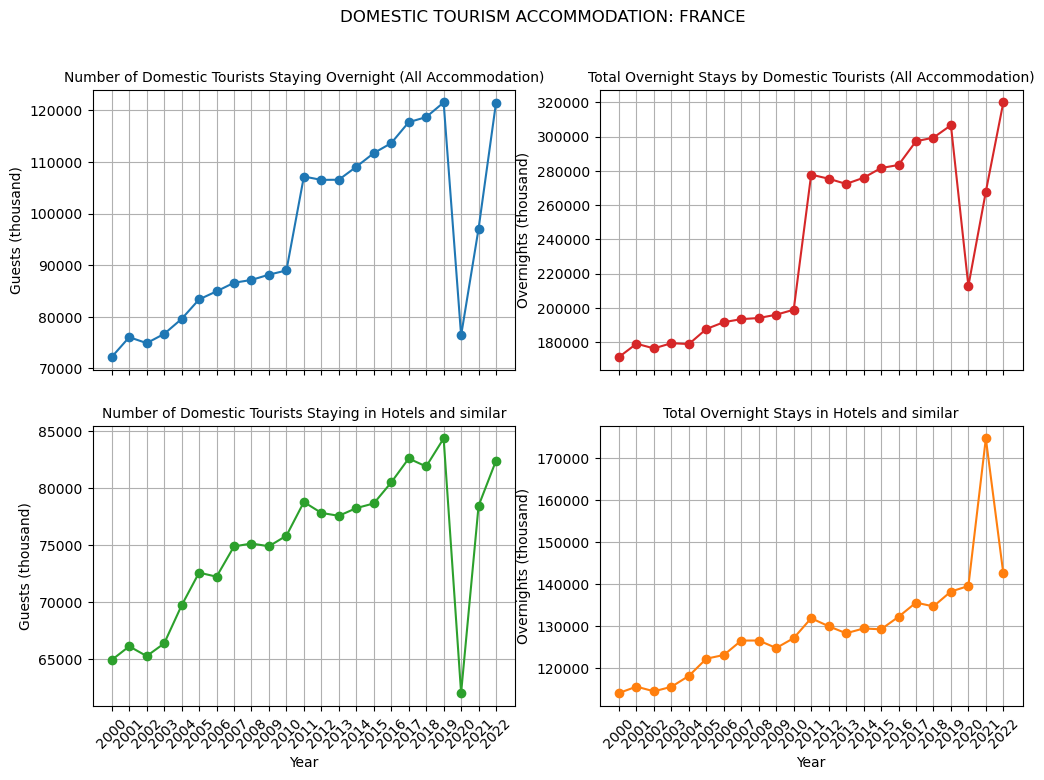

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)
plt.style.use('seaborn-v0_8-pastel')

# Guests (Accommodation) Plot
guests_acc = df_plot_acc[df_plot_acc['Indicator_name'] == 'GUESTS (ACCOMMODATION)']

axes[0,0].plot(guests_acc['Year'],
         guests_acc['Value'],
         marker = 'o',
         color = 'tab:blue')
axes[0,0].set_title('Number of Domestic Tourists Staying Overnight (All Accommodation)', fontsize='10')
axes[0,0].set_ylabel('Guests (thousand)')
axes[0,0].grid(True)

# Overnights (Accommodation) Plot
nights_acc = df_plot_acc[df_plot_acc['Indicator_name'] == 'OVERNIGHTS (ACCOMMODATION)']

axes[0,1].plot(nights_acc['Year'],
         nights_acc['Value'],
         marker = 'o',
         color = 'tab:red')
axes[0,1].set_title('Total Overnight Stays by Domestic Tourists (All Accommodation)', fontsize='10')
axes[0,1].set_ylabel('Overnights (thousand)')
axes[0,1].grid(True)

# Guests (Hotels and similar) Plot
guests_hotel = df_plot_acc[df_plot_acc['Indicator_name'] == 'GUESTS (HOTELS AND SIMILAR ESTABLISHMENTS)']

axes[1,0].plot(guests_hotel['Year'],
         guests_hotel['Value'],
         marker = 'o',
         color = 'tab:green')
axes[1,0].set_title('Number of Domestic Tourists Staying in Hotels and similar',fontsize='10')
axes[1,0].set_ylabel('Guests (thousand)')
axes[1,0].grid(True)

# Overnights (Hotels and similar) Plot
nights_hotel = df_plot_acc[df_plot_acc['Indicator_name'] == 'OVERNIGHTS (HOTELS AND SIMILAR ESTABLISHMENTS)']

axes[1,1].plot(nights_hotel['Year'],
         nights_hotel['Value'],
         marker = 'o',
         color = 'tab:orange')
axes[1,1].set_title('Total Overnight Stays in Hotels and similar', fontsize='10')
axes[1,1].set_ylabel('Overnights (thousand)')
axes[1,1].grid(True)

# Managing to share the x-axis across subplots.
axes[1,0].set_xlabel('Year')
axes[1,1].set_xlabel('Year')

axes[1,0].set_xticks(guests_hotel['Year'])
axes[1,1].set_xticks(nights_hotel['Year'])

axes[1,0].tick_params(axis='x', rotation=45)
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle(f'DOMESTIC TOURISM ACCOMMODATION: {COUNTRY}');

**Description:**

- These charts show the same trend: growth until 2019, a strong drop in 2020 and recovery after.
- The first three charts move in a similar way, showing stable domestic tourism patterns.
- Around 2010–2011, *all accommodation* increases a lot, while *hotels and similar* change only a little. This could be due to a change in data coverage.
- Overnight stays change more over time than the number of guests.
- *Overnight stays in hotels and similar* show a clear peak in 2021 compared to the other charts.

In [33]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['TOTAL TRIPS',
             'OVERNIGHTS VISITORS (TOURISTS)',
             'SAME-DAY VISITORS (EXCURSIONISTS)'
            ]

df_plot_visit = df[
    (df['Country_name'] == COUNTRY) &
    (df['Indicator_name'].isin(INDICATOR)) 
    ].sort_values('Year')

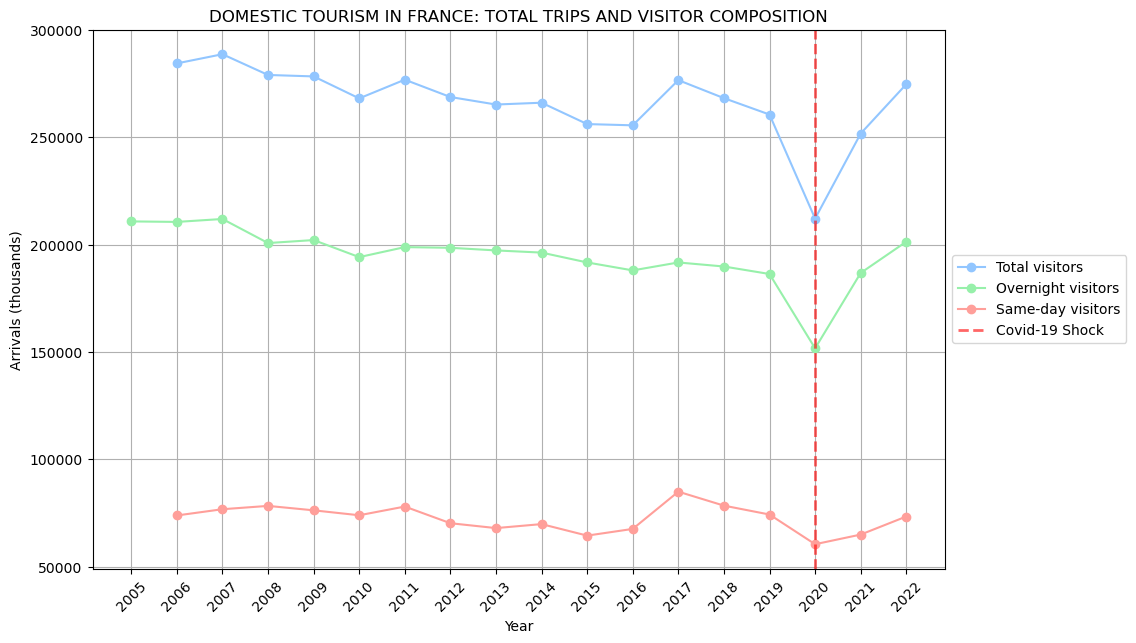

In [34]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

tot_trip1 = df_plot_visit[df_plot_visit['Indicator_name'] == 'TOTAL TRIPS']
tot_trip2 = df_plot_visit[df_plot_visit['Indicator_name'] == 'OVERNIGHTS VISITORS (TOURISTS)']
tot_trip3 = df_plot_visit[df_plot_visit['Indicator_name'] == 'SAME-DAY VISITORS (EXCURSIONISTS)']


plt.plot(tot_trip1['Year'], tot_trip1['Value'], label='Total visitors', marker='o')
plt.plot(tot_trip2['Year'], tot_trip2['Value'], label='Overnight visitors', marker='o')
plt.plot(tot_trip3['Year'], tot_trip3['Value'], label='Same-day visitors', marker='o')

years = sorted(set(tot_trip1['Year']) | set(tot_trip2['Year']) | set(tot_trip3['Year']))
plt.xticks(years, rotation=45)

plt.title(f'DOMESTIC TOURISM IN {COUNTRY}: TOTAL TRIPS AND VISITOR COMPOSITION')
plt.xlabel('Year')
plt.ylabel('Arrivals (thousands)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

**Description:**

- Total visitors and overnight visitors follow a very similar and stable trend over time.
- Series show a strong drop in 2020 and a gradual recovery after.
- Overnight visitors are always much higher than same-day visitors, this shows that domestic tourism mostly comes from based on overnight stays.
- Same-day visitors series represent a smaller part of total tourism.
- In 2022 visitor levels recovered to above 2020 values.

#### 3.2 International Tourism (Inbound) - Data Visualization

**Description:** Trips made by visitors coming into a country from abroad.

In [35]:
# Join Inbound Fact Table to Dimension Table
df_inbound_merged = (
    df2_inbound
    .merge(df_country, on="Country_key", how="left")
    .merge(df_year, on="Year_key", how="left")
    .merge(df_indicator, on="Indicator_key", how="left")
    .merge(df_units, on="Units_key", how="left")
)

In [36]:
df_inbound_merged.head()

,Country_key,Indicator_key,Year_key,Units_key,Value,Country_id,Country_name,Year,Indicator_id,Indicator_name,Source_Table,Measure_Units
0,2,14,24,4,767.0,8,ALBANIA,2018,1.29,GUESTS (ACCOMMODATION),INBOUND_ACCOMMODATION,THOUSANDS
1,2,14,25,4,785.0,8,ALBANIA,2019,1.29,GUESTS (ACCOMMODATION),INBOUND_ACCOMMODATION,THOUSANDS
2,2,14,26,4,294.0,8,ALBANIA,2020,1.29,GUESTS (ACCOMMODATION),INBOUND_ACCOMMODATION,THOUSANDS
3,2,14,27,4,685.0,8,ALBANIA,2021,1.29,GUESTS (ACCOMMODATION),INBOUND_ACCOMMODATION,THOUSANDS
4,2,14,28,4,887.0,8,ALBANIA,2022,1.29,GUESTS (ACCOMMODATION),INBOUND_ACCOMMODATION,THOUSANDS


In [37]:
single_country = df_inbound_merged['Country_name'].unique()
single_country

array(['ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA',
       'ARGENTINA', 'ARMENIA', 'ARUBA', 'AUSTRALIA', 'AUSTRIA',
       'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BARBADOS', 'BELARUS',
       'BELGIUM', 'BELIZE', 'BENIN', 'BERMUDA', 'BHUTAN', 'BOLIVIA',
       'BONAIRE', 'BOSNIA AND HERZEGOVINA', 'BOTSWANA', 'BRAZIL',
       'BRITISH VIRGIN ISLANDS', 'BRUNEI DARUSSALAM', 'BULGARIA',
       'BURKINA FASO', 'BURUNDI', 'CABO VERDE', 'CAMEROON', 'CANADA',
       'CAYMAN ISLANDS', 'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE',
       'CHINA', 'COLOMBIA', 'COMOROS', 'CONGO',
       'DEMOCRATIC REPUBLIC OF CONGO', 'COOK ISLANDS', "COTE D'IVOIRE",
       'CROATIA', 'CUBA', 'CURACAO', 'CYPRUS', 'CZECHIA', 'DENMARK',
       'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'ECUADOR', 'EGYPT',
       'EL SALVADOR', 'ERITREA', 'ESTONIA', 'ESWATINI', 'ETHIOPIA',
       'FIJI', 'FINLAND', 'FRANCE', 'FRENCH GUIANA', 'FRENCH POLYNESIA',
       'GABON', 'GEORGIA', 'GERMANY', 'GHANA', 'GREEC

In [38]:
single_indicator = df_inbound_merged['Indicator_name'].unique()
single_indicator

array(['GUESTS (ACCOMMODATION)', 'OVERNIGHTS (ACCOMMODATION)',
       'GUESTS (HOTELS AND SIMILAR ESTABLISHMENTS)',
       'OVERNIGHTS (HOTELS AND SIMILAR ESTABLISHMENTS)', 'TOTAL ARRIVALS',
       'OVERNIGHTS VISITORS (TOURISTS)',
       'SAME-DAY VISITORS (EXCURSIONISTS)', 'CRUISE PASSENGERS',
       'TOURISM EXPENDITURE IN THE COUNTRY', 'TRAVEL',
       'PASSENGER TRANSPORT', 'TOTAL PURPOSE', 'PERSONAL',
       'BUSINESS AND PROFESSIONAL', 'TOTAL REGIONS', 'AFRICA', 'AMERICAS',
       'EAST ASIA AND THE PACIFIC', 'EUROPE', 'MIDDLE EAST', 'SOUTH ASIA',
       'OTHER NOT CLASSIFIED', 'NATIONALS RESIDING ABROAD',
       'TOTAL TRANSPORT', 'AIR', 'WATER', 'LAND'], dtype=object)

In [39]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['OVERNIGHTS VISITORS (TOURISTS)',
             'SAME-DAY VISITORS (EXCURSIONISTS)',
             'TOTAL ARRIVALS'
            ]

df_arrival =  df_inbound_merged[
              (df_inbound_merged['Country_name'] == COUNTRY) &
              (df_inbound_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

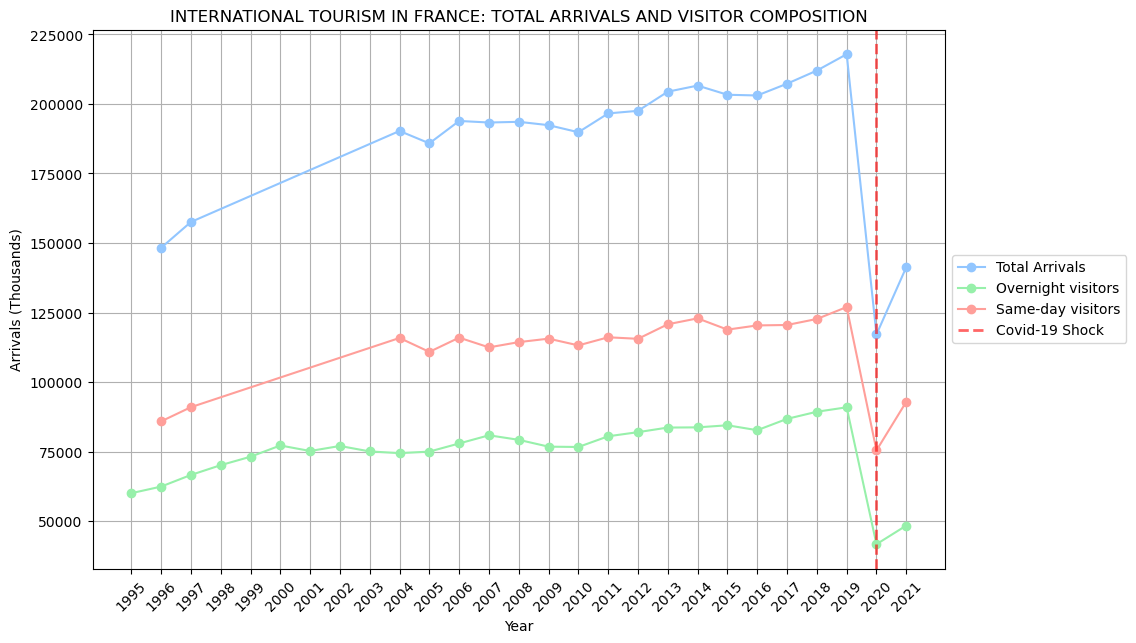

In [40]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

tot_arrival1 = df_arrival[df_arrival['Indicator_name'] == 'TOTAL ARRIVALS']
tot_arrival2 = df_arrival[df_arrival['Indicator_name'] == 'OVERNIGHTS VISITORS (TOURISTS)']
tot_arrival3 = df_arrival[df_arrival['Indicator_name'] == 'SAME-DAY VISITORS (EXCURSIONISTS)']

plt.plot(tot_arrival1['Year'], tot_arrival1['Value'], label='Total Arrivals', marker='o')
plt.plot(tot_arrival2['Year'], tot_arrival2['Value'], label='Overnight visitors', marker='o')
plt.plot(tot_arrival3['Year'], tot_arrival3['Value'], label='Same-day visitors', marker='o')

years = sorted(set(tot_arrival1['Year']) | set(tot_arrival2['Year']) | set(tot_arrival3['Year']))
plt.xticks(years, rotation=45)

plt.title(f'INTERNATIONAL TOURISM IN {COUNTRY}: TOTAL ARRIVALS AND VISITOR COMPOSITION')
plt.xlabel('Year')
plt.ylabel('Arrivals (Thousands)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

**Description:**

- Total arrivals show a clear long-term growth from 1995 to 2019, with only small fluctuations.
- Same-day visitors are consistently higher than overnight visitors, and both follow a similar trend over time.
- Data for total arrivals and same-day visitors are missing between 1997 and 2004, which should be considered when reading the early trend.
- All series show a sharp decline in 2020, indicating a strong impact on international tourism.
- A recovery appears in 2021, but visitor levels remain below pre-2020 values.

In [41]:
COUNTRY = ['FRANCE','SPAIN','ITALY','CHINA','UNITED STATES OF AMERICA']
INDICATOR = 'OVERNIGHTS VISITORS (TOURISTS)'

df_comp =  df_inbound_merged[
              (df_inbound_merged['Country_name'].isin(COUNTRY)) &
              (df_inbound_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

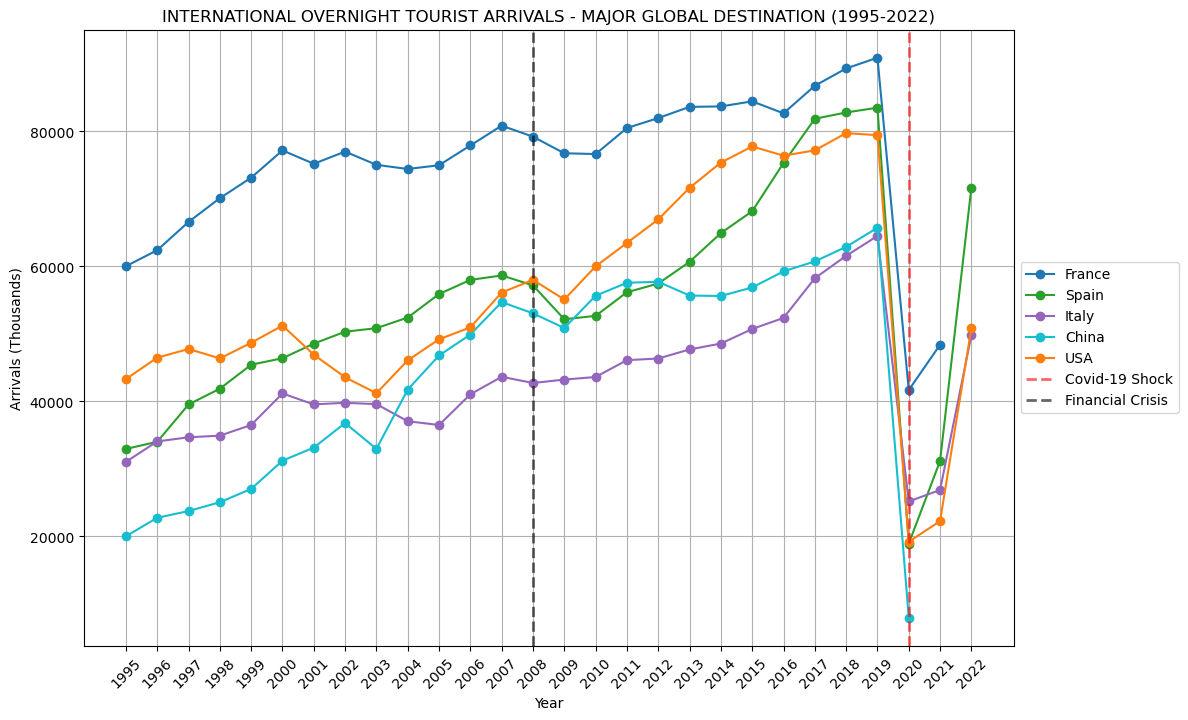

In [42]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

france = df_comp[df_comp['Country_name'] == 'FRANCE']
spain = df_comp[df_comp['Country_name'] == 'SPAIN']
italy = df_comp[df_comp['Country_name'] == 'ITALY']
china = df_comp[df_comp['Country_name'] == 'CHINA']
usa = df_comp[df_comp['Country_name'] == 'UNITED STATES OF AMERICA']

years = sorted(set(france['Year']) | set(spain['Year']) | set(china['Year']) | set(usa['Year']))
plt.xticks(years, rotation=45)

plt.plot(france['Year'], france['Value'], label='France', marker='o', color='tab:blue')
plt.plot(spain['Year'], spain['Value'], label='Spain', marker='o', color='tab:green')
plt.plot(italy['Year'], italy['Value'], label='Italy', marker='o', color='tab:purple')
plt.plot(china['Year'], china['Value'], label='China', marker='o', color='tab:cyan')
plt.plot(usa['Year'], usa['Value'], label='USA', marker='o', color='tab:orange')

plt.title('INTERNATIONAL OVERNIGHT TOURIST ARRIVALS - MAJOR GLOBAL DESTINATION (1995-2022)')
plt.xlabel('Year')
plt.ylabel('Arrivals (Thousands)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.axvline(x=2008, color='black', linewidth=2, linestyle='--', alpha=0.6, label='Financial Crisis')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid()

**Description:**

- All countries show a general growth in international tourist arrivals from 1995 to 2019.
- France remains the leading destination, while Spain shows strong growth over time.
- The USA show overall growth but also a noticeable decline in the early 2000s before recovering in later years.
- Italy grows more gradually, while China records a rapid increase, especially after the early 2000s.
- A small slowdown appears around the 2008–2009 financial crisis.
- All countries experience a sharp drop in 2020, followed by a partial recovery in 2021–2022.
- Data for China are not available after the 2020 pandemic period.

In [43]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['AFRICA','AMERICAS',
             'EAST ASIA AND THE PACIFIC', 'EUROPE', 
             'MIDDLE EAST', 'SOUTH ASIA',
             'OTHER NOT CLASSIFIED']

df_region = df_inbound_merged[              
              (df_inbound_merged['Country_name'] == COUNTRY) &
              (df_inbound_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

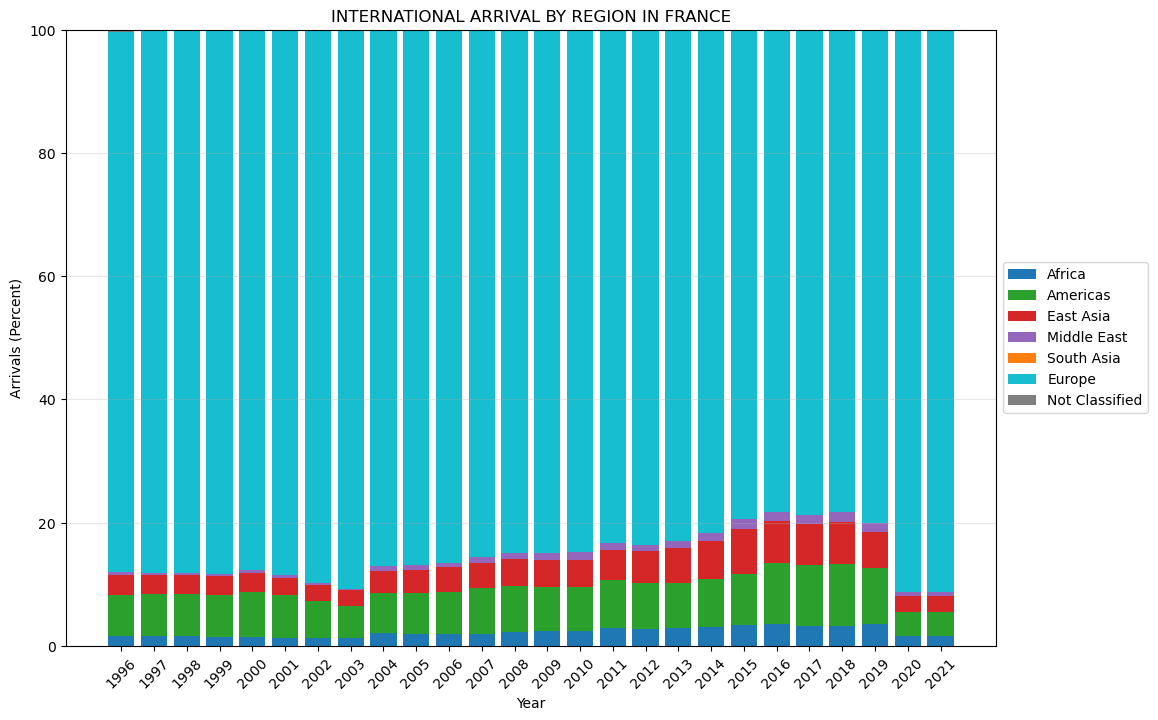

In [44]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

df_region_pct = (df_region.pivot(index='Year',columns='Indicator_name',values='Value')) # Reshape data
df_region_pct = df_region_pct.reindex(columns=INDICATOR, fill_value=0) # Add missing regions
df_region_pct = df_region_pct.apply(lambda row: (row/row.sum() * 100) if row.sum() != 0 else row, axis=1) # Convert values to %


plt.bar(df_region_pct.index, 
        df_region_pct['AFRICA'], 
        label='Africa',
        color='tab:blue') 
bottom = df_region_pct['AFRICA']

plt.bar(df_region_pct.index, 
        df_region_pct['AMERICAS'],
        bottom=bottom,
        label='Americas',
        color='tab:green') 
bottom = bottom + df_region_pct['AMERICAS']

plt.bar(df_region_pct.index, 
        df_region_pct['EAST ASIA AND THE PACIFIC'],
        bottom=bottom,
        label='East Asia',
        color='tab:red') 
bottom = bottom + df_region_pct['EAST ASIA AND THE PACIFIC']

plt.bar(df_region_pct.index, 
        df_region_pct['MIDDLE EAST'],
        bottom=bottom,
        label='Middle East',
        color='tab:purple') 
bottom = bottom + df_region_pct['MIDDLE EAST']

plt.bar(df_region_pct.index, 
        df_region_pct['SOUTH ASIA'],
        bottom=bottom,
        label='South Asia',
        color='tab:orange') 
bottom = bottom + df_region_pct['SOUTH ASIA']

plt.bar(df_region_pct.index, 
        df_region_pct['EUROPE'],
        bottom=bottom,
        label='Europe',
        color='tab:cyan') 
bottom = bottom + df_region_pct['EUROPE']

plt.bar(df_region_pct.index, 
        df_region_pct['OTHER NOT CLASSIFIED'],
        bottom=bottom,
        label='Not Classified',
        color='tab:gray') 
bottom = bottom + df_region_pct['OTHER NOT CLASSIFIED']

plt.title(f'INTERNATIONAL ARRIVAL BY REGION IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Arrivals (Percent)')
plt.xticks(df_region_pct.index, rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid(axis='y', alpha=0.3)

**Description:**

- Europe represents the largest share of international arrivals in France during the entire period.
- Other regions remain much smaller in comparison, with the Americas and East Asia showing the most visible shares after Europe.
- In 2020–2021, the composition changes because arrivals from the Americas and East Asia decline strongly.

In [45]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['AIR','WATER',
             'LAND']

df_transport = df_inbound_merged[              
              (df_inbound_merged['Country_name'] == COUNTRY) &
              (df_inbound_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

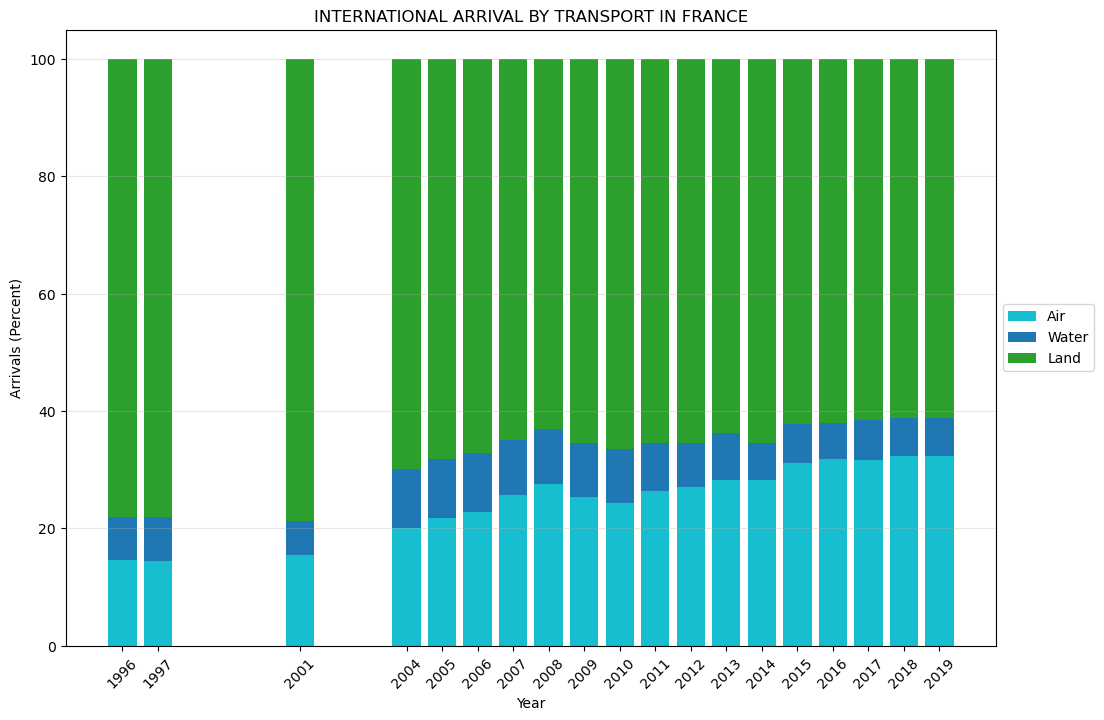

In [46]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

df_transport_pct = (df_transport.pivot(index='Year',columns='Indicator_name',values='Value')) # Reshape data
df_transport_pct = df_transport_pct.apply(lambda row: row/row.sum() * 100, axis=1) # Convert values to %


plt.bar(df_transport_pct.index, 
        df_transport_pct['AIR'], 
        label='Air',
        color='tab:cyan') 
bottom = df_transport_pct['AIR']

plt.bar(df_transport_pct.index, 
        df_transport_pct['WATER'],
        bottom=bottom,
        label='Water',
        color='tab:blue') 
bottom = bottom + df_transport_pct['WATER']

plt.bar(df_transport_pct.index, 
        df_transport_pct['LAND'],
        bottom=bottom,
        label='Land',
        color='tab:green') 
bottom = bottom + df_transport_pct['LAND']


plt.title(f'INTERNATIONAL ARRIVAL BY TRANSPORT IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Arrivals (Percent)')
plt.xticks(df_transport_pct.index, rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid(axis='y', alpha=0.3)

**Description:**

- Land transport represents the largest share of international arrivals during the period.
- Air transport increases gradually over time, showing a growing importance.
- Water transport remains a small and relatively stable share.
- The share of land transport decreases slightly as air travel becomes more common.
- Data are not available for some years (from 1998 to 2000 and from 2002 to 2003).

In [47]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['TOURISM EXPENDITURE IN THE COUNTRY',
             'TOTAL ARRIVALS'
            ]

df_exp =  df_inbound_merged[
              (df_inbound_merged['Country_name'] == COUNTRY) &
              (df_inbound_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

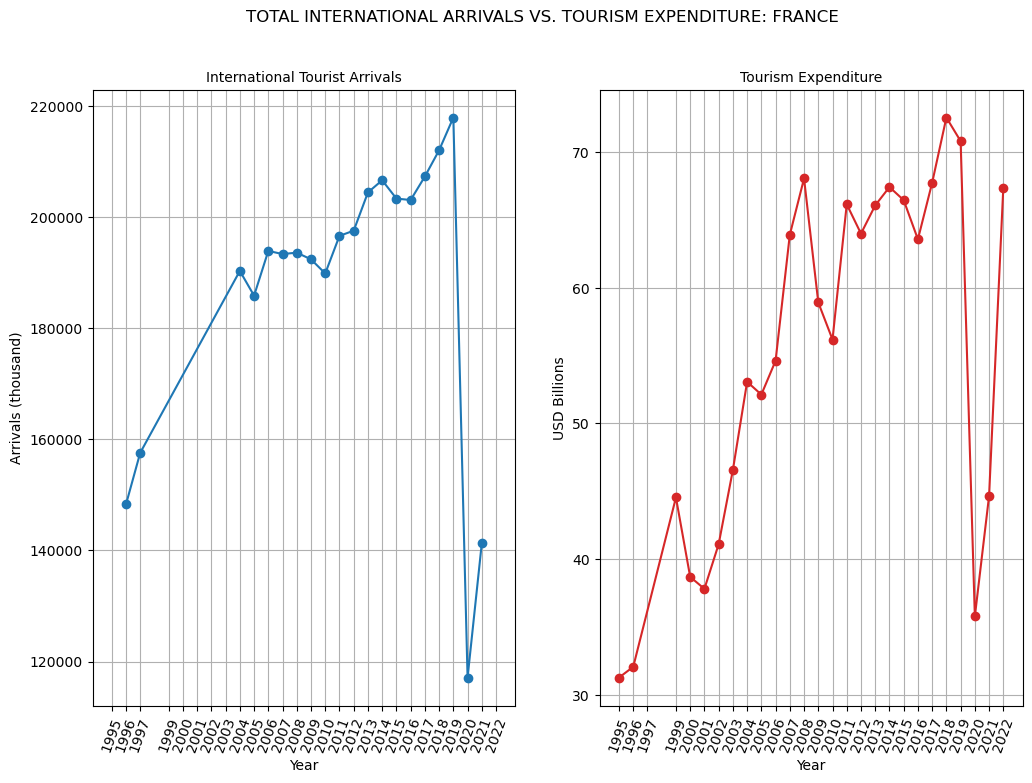

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,8), sharex=True)
plt.style.use('seaborn-v0_8-pastel')

# Total Arrivals Plot
tot_arr = df_exp[df_exp['Indicator_name'] == 'TOTAL ARRIVALS'].sort_values('Year')

axes[0].plot(tot_arr['Year'],
         tot_arr['Value'],
         marker = 'o',
         color = 'tab:blue')
axes[0].set_title('International Tourist Arrivals', fontsize='10')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Arrivals (thousand)')
axes[0].grid()

# Tourism Expenditure Plot
tot_exp = df_exp[df_exp['Indicator_name'] == 'TOURISM EXPENDITURE IN THE COUNTRY'].sort_values('Year')
tot_exp['Value_billion'] = tot_exp['Value']/1000

axes[1].plot(tot_exp['Year'],
         tot_exp['Value_billion'],
         marker = 'o',
         color = 'tab:red')
axes[1].set_title('Tourism Expenditure', fontsize='10')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('USD Billions')
axes[1].grid()

years = sorted(set(tot_arr['Year']) | set(tot_exp['Year']))

axes[0].set_xticks(years)
axes[1].set_xticks(years)

axes[0].tick_params(axis='x', rotation=70)
axes[1].tick_params(axis='x', rotation=70)

plt.suptitle(f'TOTAL INTERNATIONAL ARRIVALS VS. TOURISM EXPENDITURE: {COUNTRY}');

**Description:**

- International arrivals and tourism expenditure both show long-term growth until 2019.
- The two indicators follow a similar overall trend, suggesting a positive relationship.
- Tourism expenditure shows more fluctuations over time compared to arrivals.
- Both arrivals and expenditure decline in 2020.
- A recovery appears after 2020, but levels remain below the pre-pandemic peak.

#### 3.3 International Departures (Outbound) - Data Visualization

**Description:** Trips made by residents leaving their country to travel abroad.

In [49]:
# Join Outbound Fact Table to Dimension Table
df_outbound_merged = (
    df3_outbound
    .merge(df_country, on="Country_key", how="left")
    .merge(df_year, on="Year_key", how="left")
    .merge(df_indicator, on="Indicator_key", how="left")
    .merge(df_units, on="Units_key", how="left")
)

In [50]:
df_outbound_merged.head()

,Country_key,Indicator_key,Year_key,Units_key,Value,Country_id,Country_name,Year,Indicator_id,Indicator_name,Source_Table,Measure_Units
0,2,35,7,4,955.0,8,ALBANIA,2001,3.1,TOTAL DEPARTURES,OUTBOUND_DEPARTURES,THOUSANDS
1,2,35,8,4,1303.0,8,ALBANIA,2002,3.1,TOTAL DEPARTURES,OUTBOUND_DEPARTURES,THOUSANDS
2,2,35,9,4,1350.0,8,ALBANIA,2003,3.1,TOTAL DEPARTURES,OUTBOUND_DEPARTURES,THOUSANDS
3,2,35,10,4,1694.0,8,ALBANIA,2004,3.1,TOTAL DEPARTURES,OUTBOUND_DEPARTURES,THOUSANDS
4,2,35,11,4,2097.0,8,ALBANIA,2005,3.1,TOTAL DEPARTURES,OUTBOUND_DEPARTURES,THOUSANDS


In [51]:
single_country = df_outbound_merged['Country_name'].unique()
single_country

array(['ALBANIA', 'ALGERIA', 'ANGOLA', 'ARGENTINA', 'ARMENIA',
       'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHRAIN', 'BANGLADESH',
       'BELARUS', 'BELGIUM', 'BERMUDA', 'BHUTAN', 'BOLIVIA', 'BRAZIL',
       'BRITISH VIRGIN ISLANDS', 'BULGARIA', 'BURUNDI', 'CAMBODIA',
       'CANADA', 'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE', 'CHINA',
       'COLOMBIA', 'CONGO', 'DEMOCRATIC REPUBLIC OF CONGO',
       'COOK ISLANDS', 'COSTA RICA', "COTE D'IVOIRE", 'CROATIA', 'CUBA',
       'CYPRUS', 'CZECHIA', 'DENMARK', 'DOMINICAN REPUBLIC', 'ECUADOR',
       'EGYPT', 'EL SALVADOR', 'ESTONIA', 'ESWATINI', 'ETHIOPIA', 'FIJI',
       'FINLAND', 'FRANCE', 'FRENCH POLYNESIA', 'GABON', 'GAMBIA',
       'GEORGIA', 'GERMANY', 'GHANA', 'GREECE', 'GUADELOUPE', 'GUATEMALA',
       'HONDURAS', 'HONG KONG', 'HUNGARY', 'ICELAND', 'INDIA',
       'INDONESIA', 'IRAN', 'IRELAND', 'ISRAEL', 'ITALY', 'JAPAN',
       'JORDAN', 'KAZAKHSTAN', 'SOUTH KOREA', 'KUWAIT', 'KYRGYZSTAN',
       'LAOS', 'LATVIA', 'LIBYA', 'L

In [52]:
single_indicator = df_outbound_merged['Indicator_name'].unique()
single_indicator

array(['TOTAL DEPARTURES', 'OVERNIGHTS VISITORS (TOURISTS)',
       'SAME-DAY VISITORS (EXCURSIONISTS)',
       'TOURISM EXPENDITURE IN OTHER COUNTRIES', 'TRAVEL',
       'PASSENGER TRANSPORT'], dtype=object)

In [53]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['OVERNIGHTS VISITORS (TOURISTS)',
             'SAME-DAY VISITORS (EXCURSIONISTS)',
             'TOTAL DEPARTURES'
            ]

df_depart =  df_outbound_merged[
              (df_outbound_merged['Country_name'] == COUNTRY) &
              (df_outbound_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

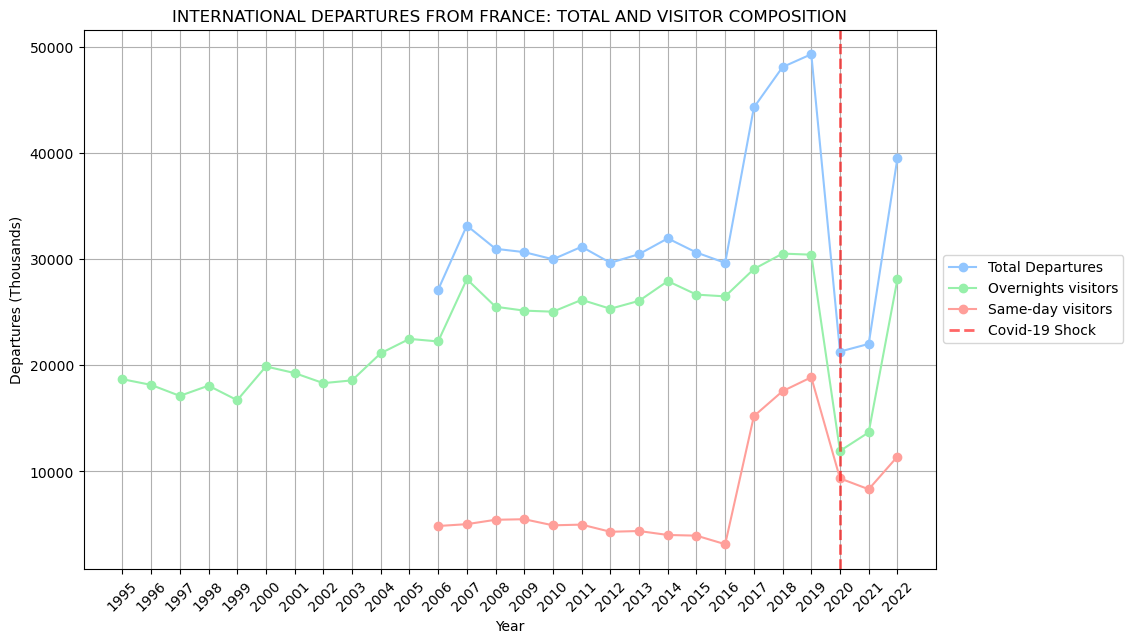

In [54]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

tot_depart1 = df_depart[df_depart['Indicator_name'] == 'TOTAL DEPARTURES']
tot_depart2 = df_depart[df_depart['Indicator_name'] == 'OVERNIGHTS VISITORS (TOURISTS)']
tot_depart3 = df_depart[df_depart['Indicator_name'] == 'SAME-DAY VISITORS (EXCURSIONISTS)']

plt.plot(tot_depart1['Year'], tot_depart1['Value'], label='Total Departures', marker='o')
plt.plot(tot_depart2['Year'], tot_depart2['Value'], label='Overnights visitors', marker='o')
plt.plot(tot_depart3['Year'], tot_depart3['Value'], label='Same-day visitors', marker='o')

years = sorted(set(tot_depart1['Year']) | set(tot_depart2['Year']) | set(tot_depart3['Year']))
plt.xticks(years, rotation=45)

plt.title(f'INTERNATIONAL DEPARTURES FROM {COUNTRY}: TOTAL AND VISITOR COMPOSITION')
plt.xlabel('Year')
plt.ylabel('Departures (Thousands)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

**Description:**

- Total international departures show a general upward trend until 2019.
- Overnight visitors represent the largest share of departures during the period.
- Same-day visitors increase after 2016 compared to earlier years.
- All series recorded a decline in 2020.
- A recovery is observed in 2021–2022, although levels remain unstable.

In [55]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'TOURISM EXPENDITURE IN OTHER COUNTRIES'

df_exp_dep =  df_outbound_merged[
              (df_outbound_merged['Country_name'] == COUNTRY) &
              (df_outbound_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

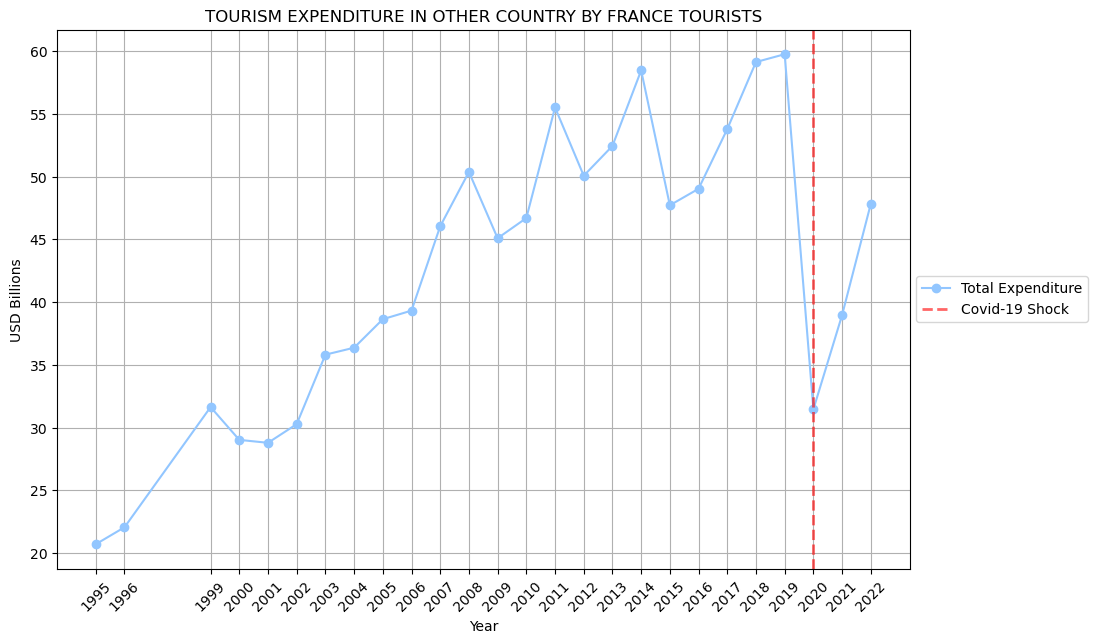

In [56]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

df_exp_dep['Value_billion'] = df_exp_dep['Value']/1000
plt.plot(df_exp_dep['Year'], df_exp_dep['Value_billion'], label='Total Expenditure', marker='o')


plt.title(f'TOURISM EXPENDITURE IN OTHER COUNTRY BY {COUNTRY} TOURISTS')
plt.xlabel('Year')
plt.ylabel('USD Billions')
plt.xticks(df_exp_dep['Year'], rotation=45)
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

**Description:**

- Tourism expenditure abroad by French tourists shows a general upward trend until 2019.
- Some fluctuations appear over time, but the overall trend remains positive.
- Expenditure had a significant drop in 2020.
- A recovery appears in 2021–2022, although levels remain below the pre-pandemic peak.

#### 3.4 Tourism Industries - Data Visualization

**Description:** Data about tourism infrastructure, including establishments, rooms, and accommodation capacity.

In [57]:
# Join Tourism Industries Fact Table to Dimension Table
df_industries_merged = (
    df4_industries
    .merge(df_country, on="Country_key", how="left")
    .merge(df_year, on="Year_key", how="left")
    .merge(df_indicator, on="Indicator_key", how="left")
    .merge(df_units, on="Units_key", how="left")
)

In [58]:
df_industries_merged.head()

,Country_key,Indicator_key,Year_key,Units_key,Value,Country_id,Country_name,Year,Indicator_id,Indicator_name,Source_Table,Measure_Units
0,2,41,24,2,1021.0,8,ALBANIA,2018,4.13,NUMBER OF ESTABLISHMENTS,TOURISM_INDUSTRIES,NUMBER
1,2,41,25,2,1126.0,8,ALBANIA,2019,4.13,NUMBER OF ESTABLISHMENTS,TOURISM_INDUSTRIES,NUMBER
2,2,41,26,2,1237.0,8,ALBANIA,2020,4.13,NUMBER OF ESTABLISHMENTS,TOURISM_INDUSTRIES,NUMBER
3,2,41,27,2,1256.0,8,ALBANIA,2021,4.13,NUMBER OF ESTABLISHMENTS,TOURISM_INDUSTRIES,NUMBER
4,2,41,28,2,1385.0,8,ALBANIA,2022,4.13,NUMBER OF ESTABLISHMENTS,TOURISM_INDUSTRIES,NUMBER


In [59]:
single_country = df_industries_merged['Country_name'].unique()
single_country

array(['ALBANIA', 'ALGERIA', 'AMERICAN SAMOA', 'ANDORRA', 'ANGOLA',
       'ANGUILLA', 'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'ARUBA',
       'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN',
       'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN',
       'BERMUDA', 'BHUTAN', 'BOLIVIA', 'BONAIRE',
       'BOSNIA AND HERZEGOVINA', 'BOTSWANA', 'BRAZIL',
       'BRITISH VIRGIN ISLANDS', 'BRUNEI DARUSSALAM', 'BULGARIA',
       'BURKINA FASO', 'BURUNDI', 'CABO VERDE', 'CAMBODIA', 'CAMEROON',
       'CANADA', 'CAYMAN ISLANDS', 'CENTRAL AFRICAN REPUBLIC', 'CHAD',
       'CHILE', 'CHINA', 'COLOMBIA', 'COMOROS', 'CONGO',
       'DEMOCRATIC REPUBLIC OF CONGO', 'COOK ISLANDS', 'COSTA RICA',
       "COTE D'IVOIRE", 'CROATIA', 'CUBA', 'CURACAO', 'CYPRUS', 'CZECHIA',
       'DENMARK', 'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'ECUADOR',
       'EGYPT', 'EL SALVADOR', 'ERITREA', 'ESTONIA', 'ESWATINI',
       'ETHIOPIA', 'FIJI', 'FINLAND', 'FRANCE', 'FRENCH GUIAN

In [60]:
single_indicator = df_industries_merged['Indicator_name'].unique()
single_indicator

array(['NUMBER OF ESTABLISHMENTS', 'NUMBER OF ROOMS',
       'NUMBER OF BED-PLACES', 'OCCUPANCY RATE / ROOMS',
       'OCCUPANCY RATE / BED-PLACES', 'AVERAGE LENGTH OF STAY',
       'AVAILABLE CAPACITY (BED-PLACES PER 1000 INHABITANS)'],
      dtype=object)

In [61]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'NUMBER OF ESTABLISHMENTS'

df_esta =  df_industries_merged[
              (df_industries_merged['Country_name'] == COUNTRY) &
              (df_industries_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

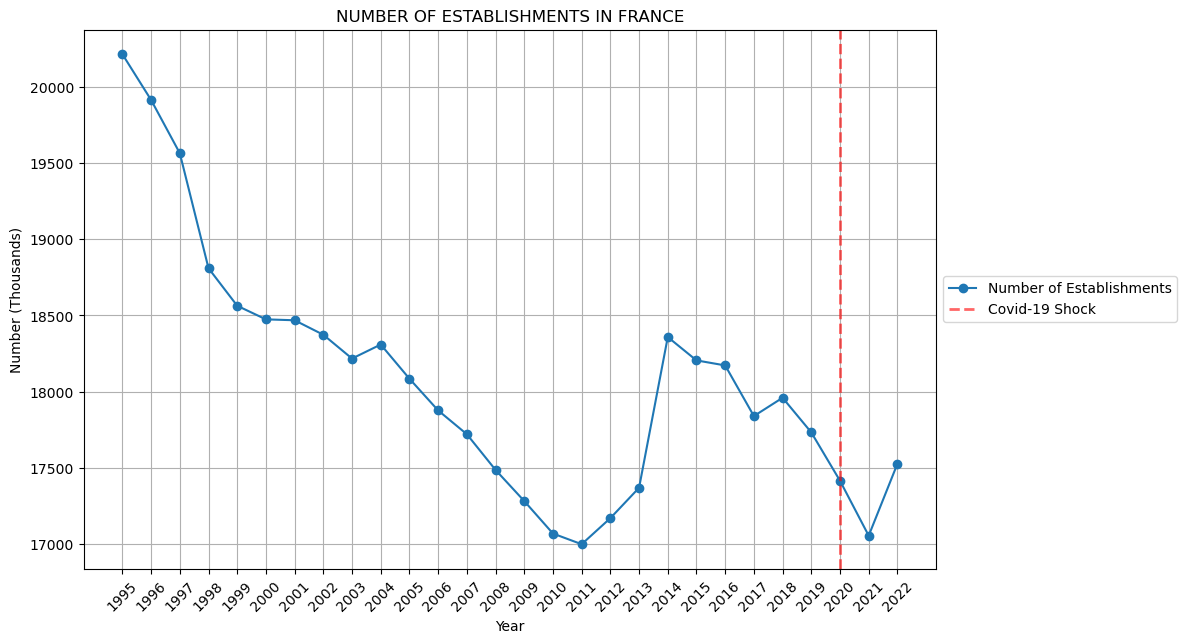

In [62]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

plt.plot(df_esta['Year'], df_esta['Value'], label='Number of Establishments', marker='o', color='tab:blue')

plt.title(f'NUMBER OF ESTABLISHMENTS IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Number (Thousands)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.xticks(df_esta['Year'], rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

In [63]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'NUMBER OF ROOMS'

df_rooms =  df_industries_merged[
              (df_industries_merged['Country_name'] == COUNTRY) &
              (df_industries_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

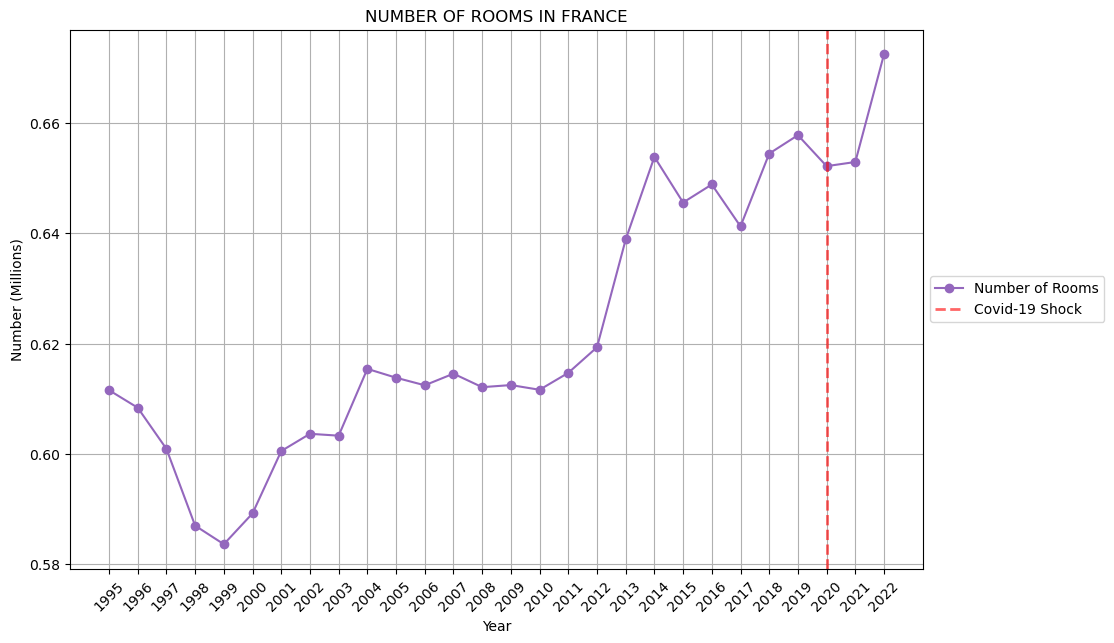

In [64]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

df_rooms['Value_millions'] = df_rooms['Value']/1000000

plt.plot(df_rooms['Year'], df_rooms['Value_millions'], label='Number of Rooms', marker='o', color='tab:purple')

plt.title(f'NUMBER OF ROOMS IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Number (Millions)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.xticks(df_rooms['Year'], rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

In [65]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'NUMBER OF BED-PLACES'

df_bed =  df_industries_merged[
              (df_industries_merged['Country_name'] == COUNTRY) &
              (df_industries_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

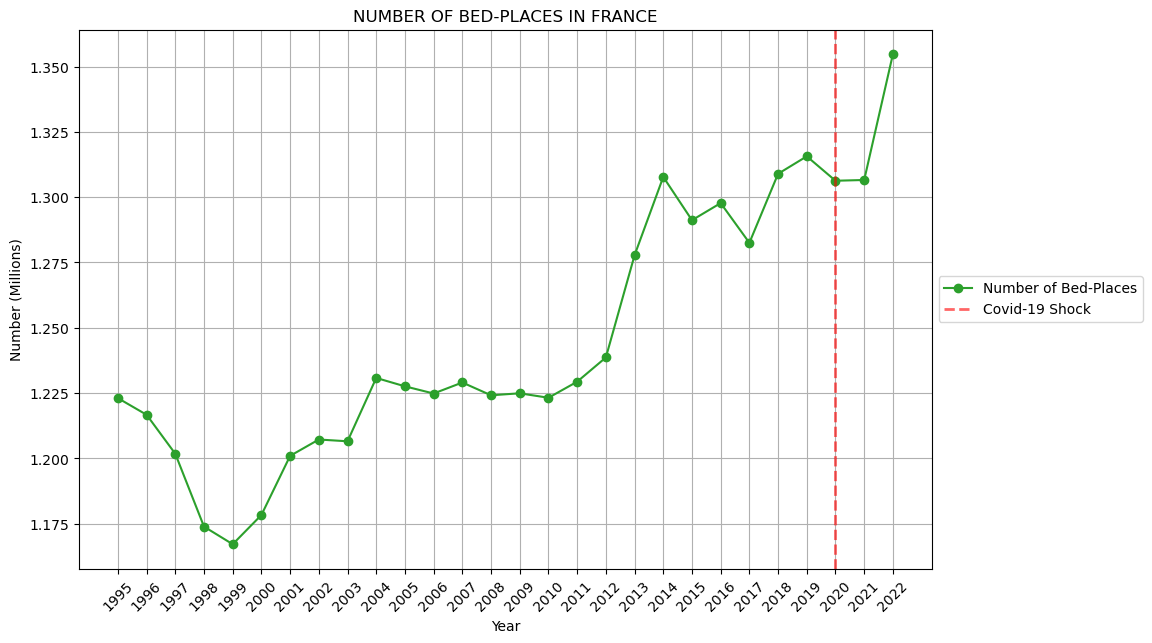

In [66]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

df_bed['Value_millions'] = df_bed['Value']/1000000

plt.plot(df_bed['Year'], df_bed['Value_millions'], label='Number of Bed-Places', marker='o', color='tab:green')

plt.title(f'NUMBER OF BED-PLACES IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Number (Millions)')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.xticks(df_bed['Year'], rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

In [67]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = ['NUMBER OF ESTABLISHMENTS','NUMBER OF ROOMS']

df =  df_industries_merged[
              (df_industries_merged['Country_name'] == COUNTRY) &
              (df_industries_merged['Indicator_name'].isin(INDICATOR))
               ].sort_values('Year')

In [68]:
df_capacity = df.pivot( 
              index = 'Year',
              columns = 'Indicator_name',
              values = 'Value'
              )

In [69]:
df_capacity['Avg_Rooms'] = (df_capacity['NUMBER OF ROOMS']/df_capacity['NUMBER OF ESTABLISHMENTS'])

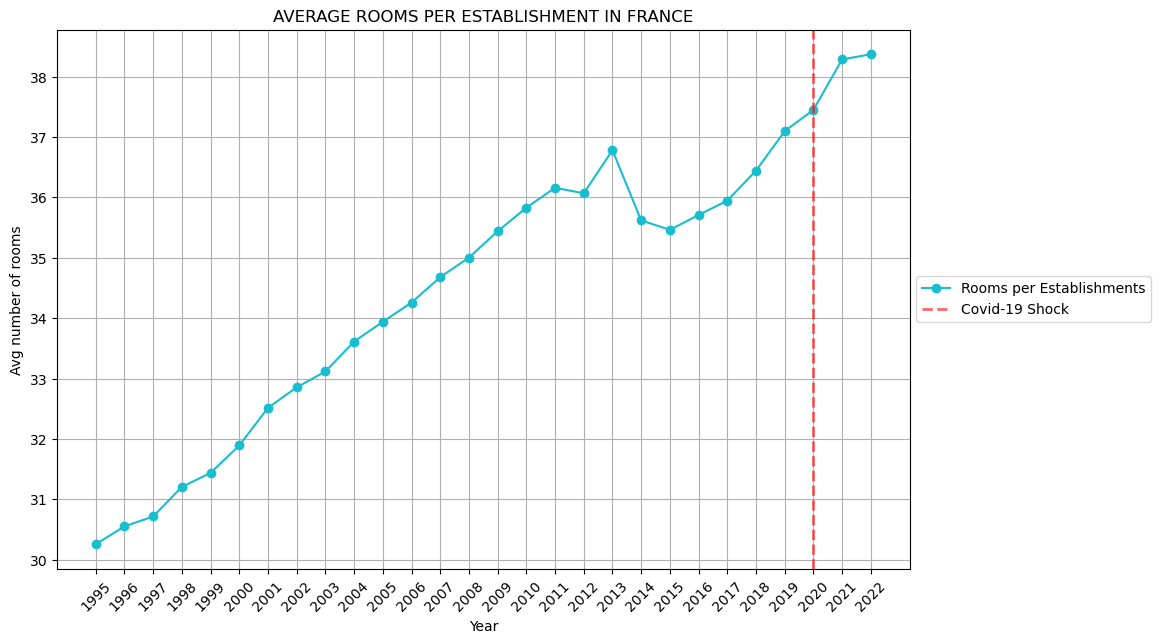

In [70]:
plt.figure(figsize=(11,7))
plt.style.use('seaborn-v0_8-pastel')

plt.plot(df_capacity.index, df_capacity['Avg_Rooms'], label='Rooms per Establishments', marker='o', color='tab:cyan')

plt.title(f'AVERAGE ROOMS PER ESTABLISHMENT IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Avg number of rooms')
plt.axvline(x=2020, color='red', linewidth=2, linestyle='--', alpha=0.6, label='Covid-19 Shock')
plt.xticks(df_capacity.index, rotation=45)
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.grid();

**Description:**

- The average number of rooms per establishment shows a steady upward trend over time.
- A small slowdown appears around 2013–2015.
- Growth resumes after 2016.
- No strong decline is visible around 2020 despite the Covid-19 period.

> **Methodological Note:**
> The average number of rooms per establishment was calculated by dividing the total number of rooms by the total number of establishments.  
> This indicator was created to better understand structural changes in accommodation capacity over time, since the number of establishments and the number of rooms follow different trends.

In [71]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'AVERAGE LENGTH OF STAY'

df_lenght =  df_industries_merged[
              (df_industries_merged['Country_name'] == COUNTRY) &
              (df_industries_merged['Indicator_name'] == INDICATOR)
               ].sort_values('Year')

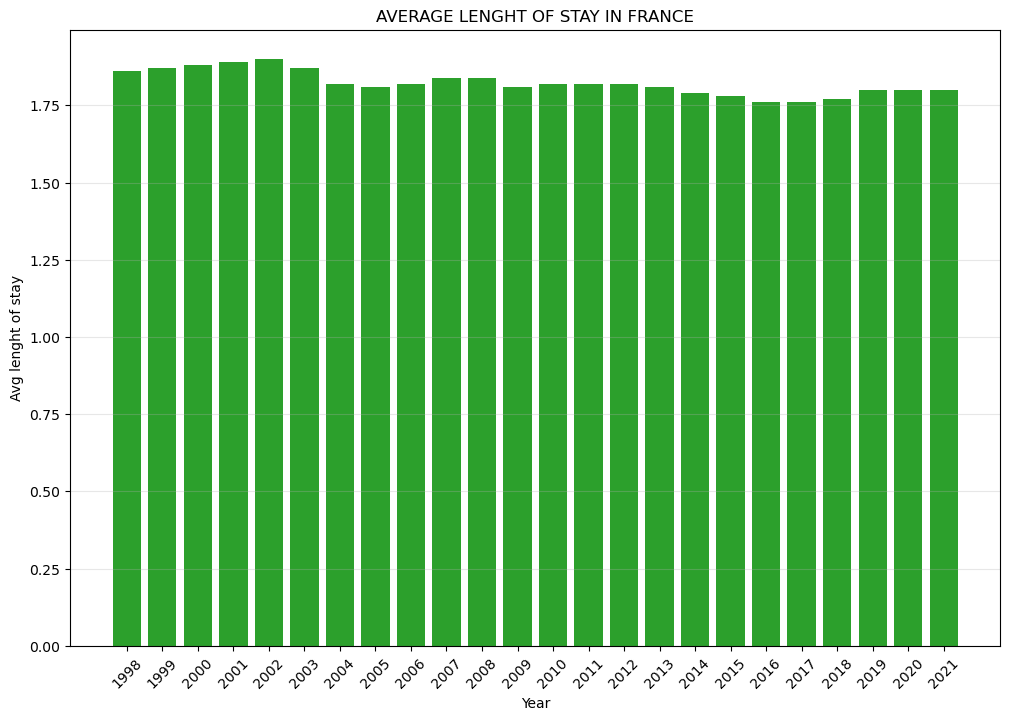

In [72]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

plt.bar(df_lenght['Year'], df_lenght['Value'], color='tab:green')
plt.xticks(df_lenght['Year'], rotation=45)

plt.title(f'AVERAGE LENGHT OF STAY IN {COUNTRY}')
plt.xlabel('Year')
plt.ylabel('Avg lenght of stay')
plt.grid(axis='y', alpha=0.3)

**Description:**

- The average length of stay remains relatively stable over time.
- A small increase appears in the early 2000s.
- A gradual slight decline is visible in later years.
- No strong variation is observed around the Covid-19 period.
- Overall values fluctuate within a narrow range.

#### 3.5 SDG Indicator - Data Visualization

**Description:** Shows a Sustainable Development Goal (SDG) tourism indicator.

In [73]:
# Join Tourism SDG Fact Table to Dimension Table
df_sdg_merged = (
    df5_sdg
    .merge(df_country, on="Country_key", how="left")
    .merge(df_year, on="Year_key", how="left")
    .merge(df_units, on="Units_key", how="left")
)

In [74]:
df_sdg_merged.head()

,Country_key,Indicator,Year_key,Units_key,Value,Country_id,Country_name,Year,Measure_Units
0,2,SDG_8.9.1_GDP,14,3,2.76,8,ALBANIA,2008,PERCENT
1,2,SDG_8.9.1_GDP,15,3,2.67,8,ALBANIA,2009,PERCENT
2,2,SDG_8.9.1_GDP,16,3,2.81,8,ALBANIA,2010,PERCENT
3,2,SDG_8.9.1_GDP,17,3,2.53,8,ALBANIA,2011,PERCENT
4,2,SDG_8.9.1_GDP,18,3,2.36,8,ALBANIA,2012,PERCENT


In [75]:
single_country = df_sdg_merged['Country_name'].unique()
single_country

array(['ALBANIA', 'ALGERIA', 'ANTIGUA AND BARBUDA', 'AZERBAIJAN',
       'ARGENTINA', 'AUSTRALIA', 'AUSTRIA', 'BAHAMAS', 'BAHRAIN',
       'BANGLADESH', 'BELGIUM', 'BERMUDA', 'BHUTAN', 'BOTSWANA',
       'BRITISH VIRGIN ISLANDS', 'BRUNEI DARUSSALAM', 'BELARUS',
       'CAMEROON', 'CANADA', 'SRI LANKA', 'CHILE', 'COLOMBIA',
       'COSTA RICA', 'CROATIA', 'CZECHIA', 'DENMARK', 'ECUADOR',
       'EL SALVADOR', 'EQUATORIAL GUINEA', 'ETHIOPIA', 'ESTONIA', 'FIJI',
       'FINLAND', 'FRANCE', 'FRENCH POLYNESIA', 'STATE OF PALESTINE',
       'GERMANY', 'KIRIBATI', 'GREECE', 'GUAM', 'GUINEA', 'GUYANA',
       'HONDURAS', 'HONG KONG', 'HUNGARY', 'ICELAND', 'INDIA',
       'INDONESIA', 'IRELAND', 'ISRAEL', 'ITALY', "COTE D'IVOIRE",
       'JAMAICA', 'JAPAN', 'KAZAKHSTAN', 'JORDAN', 'KENYA', 'SOUTH KOREA',
       'KUWAIT', 'KYRGYZSTAN', 'LEBANON', 'LATVIA', 'LITHUANIA',
       'LUXEMBOURG', 'MACAO', 'MALAWI', 'MALAYSIA', 'MALTA', 'MARTINIQUE',
       'MAURITIUS', 'MEXICO', 'MONGOLIA', 'MOLDOVA', 

In [76]:
single_indicator = df_sdg_merged['Indicator'].unique()
single_indicator

array(['SDG_8.9.1_GDP', 'SDG_8.9.2_EMP', 'SDG_12.b.1_SEEA'], dtype=object)

In [77]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'SDG_8.9.1_GDP'

df_gdp = df_sdg_merged[
        (df_sdg_merged['Country_name'] == COUNTRY) &
        (df_sdg_merged['Indicator'] == INDICATOR)
        ].sort_values('Year')

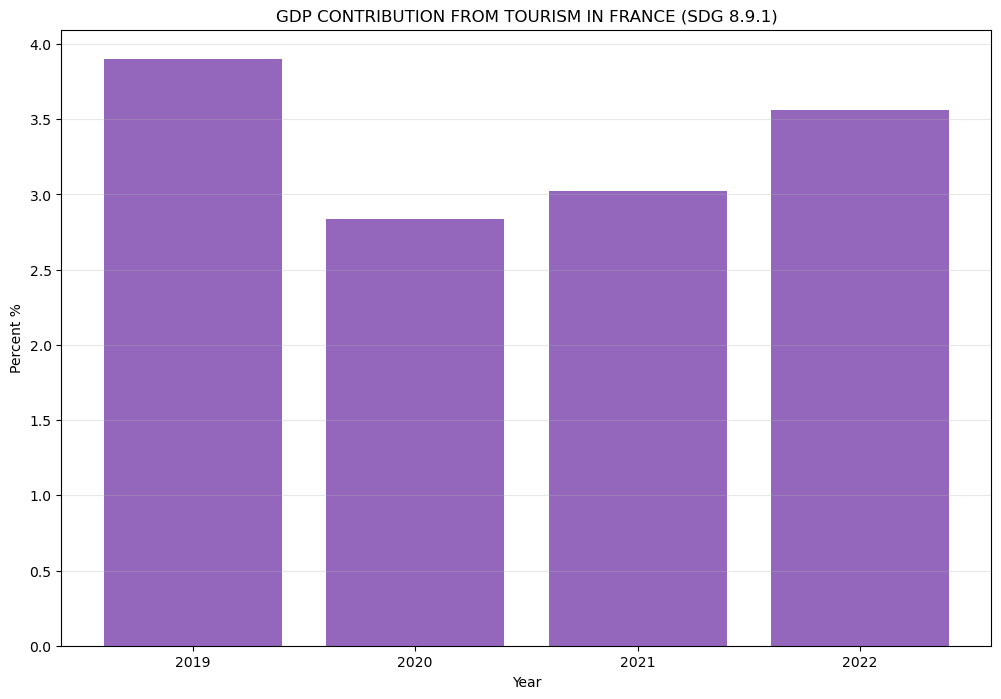

In [78]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

plt.bar(df_gdp['Year'],df_gdp['Value'], color='tab:purple')
plt.xticks(df_gdp['Year'])

plt.title(f'GDP CONTRIBUTION FROM TOURISM IN {COUNTRY} (SDG 8.9.1)')
plt.xlabel('Year')
plt.ylabel('Percent %')
plt.grid(axis='y', alpha=0.3)

**Description:**

- Tourism contribution to GDP decreases in 2020 (data for France are available only for these years).
- A gradual recovery appears in 2021 and continues in 2022.
- The 2022 value increases compared to previous years but remains slightly below the 2019 level.

In [79]:
COUNTRY = 'FRANCE' # Change this value to generate the report for another country
INDICATOR = 'SDG_8.9.2_EMP'

df_emp = df_sdg_merged[
        (df_sdg_merged['Country_name'] == COUNTRY) &
        (df_sdg_merged['Indicator'] == INDICATOR)
        ].sort_values('Year')

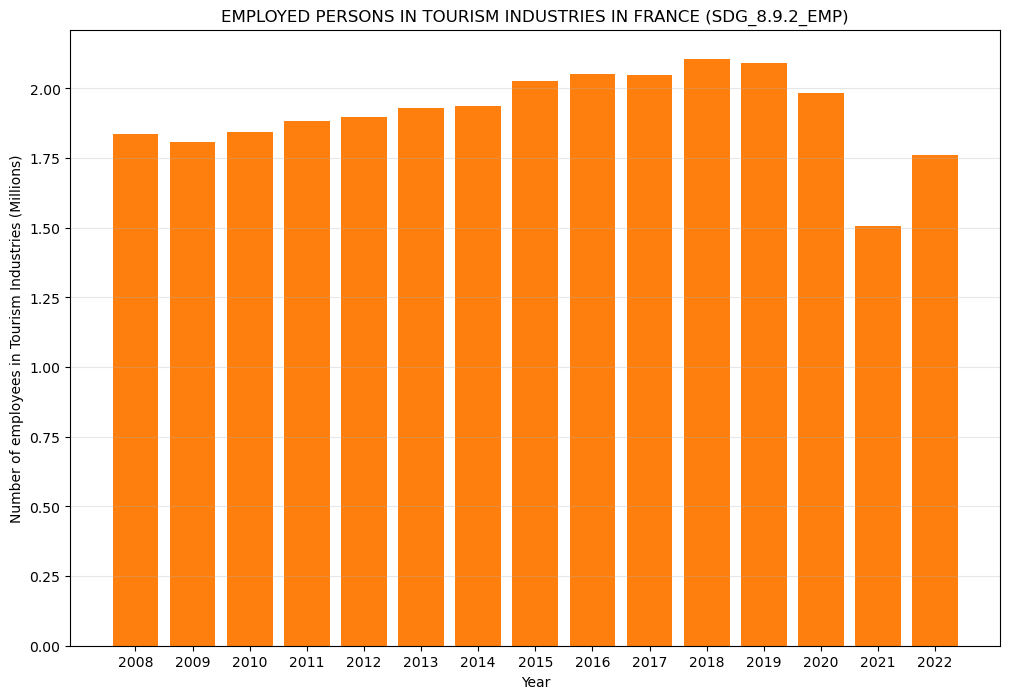

In [80]:
plt.figure(figsize=(12,8))
plt.style.use('seaborn-v0_8-pastel')

df_emp['Value_millions'] = df_emp['Value']/1000000

plt.bar(df_emp['Year'],df_emp['Value_millions'], color='tab:orange')
plt.xticks(df_emp['Year'])

plt.title(f'EMPLOYED PERSONS IN TOURISM INDUSTRIES IN {COUNTRY} (SDG_8.9.2_EMP)')
plt.xlabel('Year')
plt.ylabel('Number of employees in Tourism Industries (Millions)')
plt.grid(axis='y', alpha=0.3)

**Description:**

- Employment in tourism industries shows a gradual increase from 2008 to 2019.
- A decline appears in 2020 and becomes stronger in 2021.
- Employment recovers partially in 2022.
- Levels remain below the pre-pandemic peak.

## Final Summary

This analysis explores how tourism has changed over time using data from a tourism data warehouse. It examines domestic tourism, international arrivals and departures, tourism industries, and selected sustainability indicators, with a focus on France.

The results show steady tourism growth before 2020, followed by a strong disruption during the Covid-19 pandemic. In recent years, tourism has gradually started to recover, although recovery patterns differ across indicators.

During the analysis, attention was given to data structure and statistical definitions. For example, some Sustainable Development Goal (SDG) indicators include multiple records for the same country and year. These were kept because they represent different measurement series rather than duplicated data.

Overall, the project demonstrates a complete analytical workflow: extracting data from a data warehouse, validating datasets, and visualizing tourism trends while remaining consistent with a structured data model.

**Country selection note:** France was chosen as a reference country because it provides consistent records across most tourism indicators. Its high tourism activity and strong data coverage make it a suitable example for showing long-term trends and methodological choices.